
Las clases desbalanceadas se refieren a una situación en la que el conjunto de datos utilizado para entrenar un modelo de machine learning presenta una proporción significativamente desigual entre las diferentes clases que se deben predecir. En otras palabras, algunas categorías tienen muchas más instancias que otras, lo que puede afectar negativamente el rendimiento del modelo.

Este desbalance puede surgir en diversas aplicaciones, como la detección de fraudes, diagnósticos médicos o la clasificación de eventos raros. El problema radica en que el modelo puede volverse sesgado hacia la clase dominante, dando como resultado predicciones menos precisas para las clases minoritarias.

Existen varias estrategias para abordar las clases desbalanceadas, como el submuestreo y sobre-muestreo de datos, el uso de pesos de clase durante el entrenamiento, o la implementación de algoritmos específicos diseñados para manejar este desafío, como Random Forest o Support Vector Machines con técnicas de ajuste de costos.

En resumen, el manejo adecuado de clases desbalanceadas es esencial para asegurar que un modelo de machine learning sea capaz de generalizar de manera efectiva y realizar predicciones precisas en todas las clases, independientemente de su frecuencia en el conjunto de datos.

<img src="desbalancedatos.PNG">

El conjunto de datos que trabajaremos presenta transacciones que ocurrieron en dos días en Europa en 2013, donde tenemos 492 fraudes de 284,807 transacciones. El conjunto de datos está muy desequilibrado: la clase positiva (fraudes) representa el 0,172% de todas las transacciones.

Contiene sólo variables de entrada numéricas que son el resultado de una transformación PCA. Lamentablemente, debido a cuestiones de confidencialidad, no podemos proporcionar las características originales ni más información general sobre los datos. Las características V1, V2,… V28 son los componentes principales obtenidos con PCA, las únicas características que no se han transformado con PCA son 'Tiempo' y 'Cantidad'. La característica 'Tiempo' contiene los segundos transcurridos entre cada transacción y la primera transacción en el conjunto de datos. La característica 'Monto' es el monto de la transacción; esta característica se puede utilizar para el aprendizaje sensible a los costos, por ejemplo. La característica 'Clase' es la variable de respuesta y toma el valor 1 en caso de fraude y 0 en caso contrario.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeClassifier, 
                         DecisionTreeRegressor,
                         plot_tree,
                         export_graphviz)
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score,accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import AdaBoostClassifier,AdaBoostRegressor,RandomForestRegressor,RandomForestClassifier
from xgboost import  XGBClassifier,XGBRegressor
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.feature_selection import SelectKBest, chi2, f_classif

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE,BorderlineSMOTE,ADASYN
from imblearn.pipeline import Pipeline

In [8]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.shape ### 284807 registros con 31 columnas

(284807, 31)

In [4]:
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [5]:
df.dtypes ### todas las variables son de tipo numerico

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [6]:
df.isnull().sum() ### afortunadamente sin datos faltantes

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Ajustemos directamente un modelo de aprendizaje supervisado, tomemos por ejemplo un xgboost y evaluemos como lo hemos hecho en clases anteriores

In [9]:
X=df.drop(columns="Class")
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)


xgb_model = XGBClassifier().fit(X_train,Y_train)
y_pred= xgb_model.predict(X_test)
print("xgb_model accuracy en train,",xgb_model.score(X_train,Y_train))
print("xgb_model accuracy en test,",xgb_model.score(X_test,Y_test)) ### el modelo se ve super bien

xgb_model accuracy en train, 1.0
xgb_model accuracy en test, 0.9995435553526912


<Axes: >

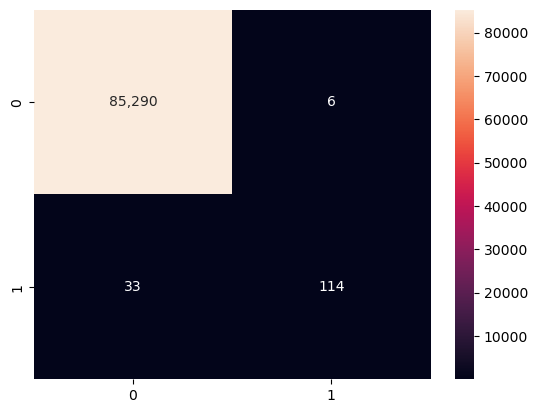

In [10]:
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales

In [5]:
114/(114+33)

0.7755102040816326

In [1]:
85290+6+33+114

85443

In [3]:
85290/85443

0.9982093325374811

In [11]:
cvscore=cross_validate(xgb_model,X_train,Y_train,cv=5,scoring="accuracy")
cvscore["test_score"].mean()

0.9995285008584036

In [12]:
### el accuracy aqui está siendo engañoso ya que lo que logra clasificar muy bien es la clase mayoritaria (no fraude), sin embargo lo que buscamos estimar es la clase 1 (fraude)

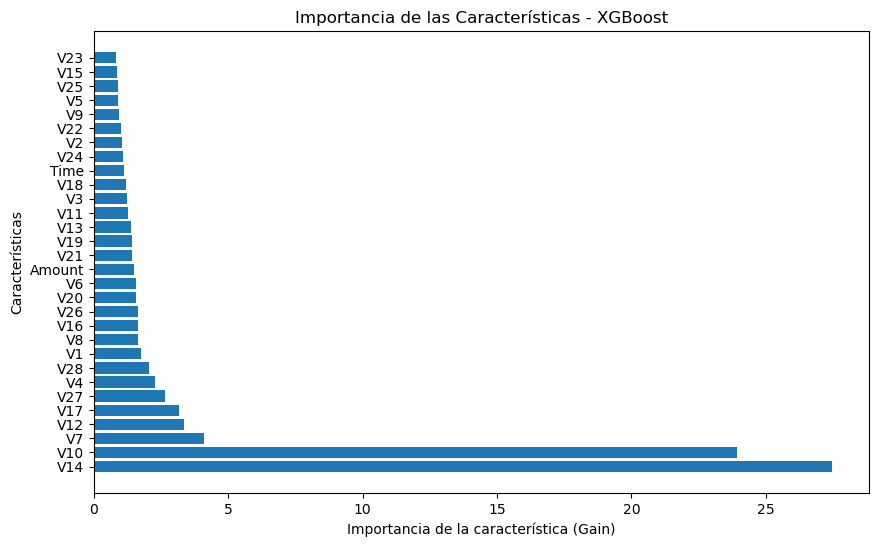

In [13]:
### vemos que variables fueron utiles para el xgboost en este problema
feature_importance_gain=xgb_model.get_booster().get_score(importance_type="gain")
sorted_feature_importance_gain = sorted(feature_importance_gain.items(), key=lambda x: x[1], reverse=True)
features, gains = zip(*sorted_feature_importance_gain)

# Crea un gráfico de barras
plt.figure(figsize=(10, 6))
plt.barh(range(len(features)), gains, align="center")
plt.yticks(range(len(features)), features)
plt.xlabel("Importancia de la característica (Gain)")
plt.ylabel("Características")
plt.title("Importancia de las Características - XGBoost")
plt.show()

#### HACEMOS ANALISIS NUEVAMENTE

In [16]:
print(df[df.Class==0].shape)
print(df[df.Class==1].shape)

(284315, 31)
(492, 31)


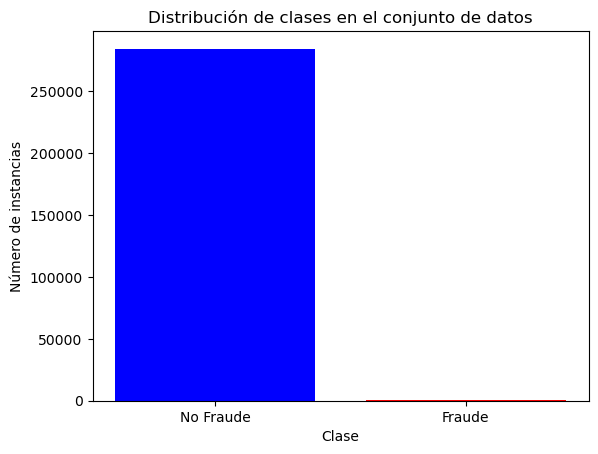

In [18]:
class_counts = df['Class'].value_counts()

plt.bar(class_counts.index, class_counts.values, color=['blue', 'red'])
plt.xlabel('Clase')
plt.ylabel('Número de instancias')
plt.title('Distribución de clases en el conjunto de datos')
plt.xticks(class_counts.index, ['No Fraude', 'Fraude'])
plt.show()

In [19]:
### vale la pena hacer un grafico con la distribución de cada uno de las variables y ver cuales discriminan mejor las
### dos clases

<Figure size 640x480 with 0 Axes>

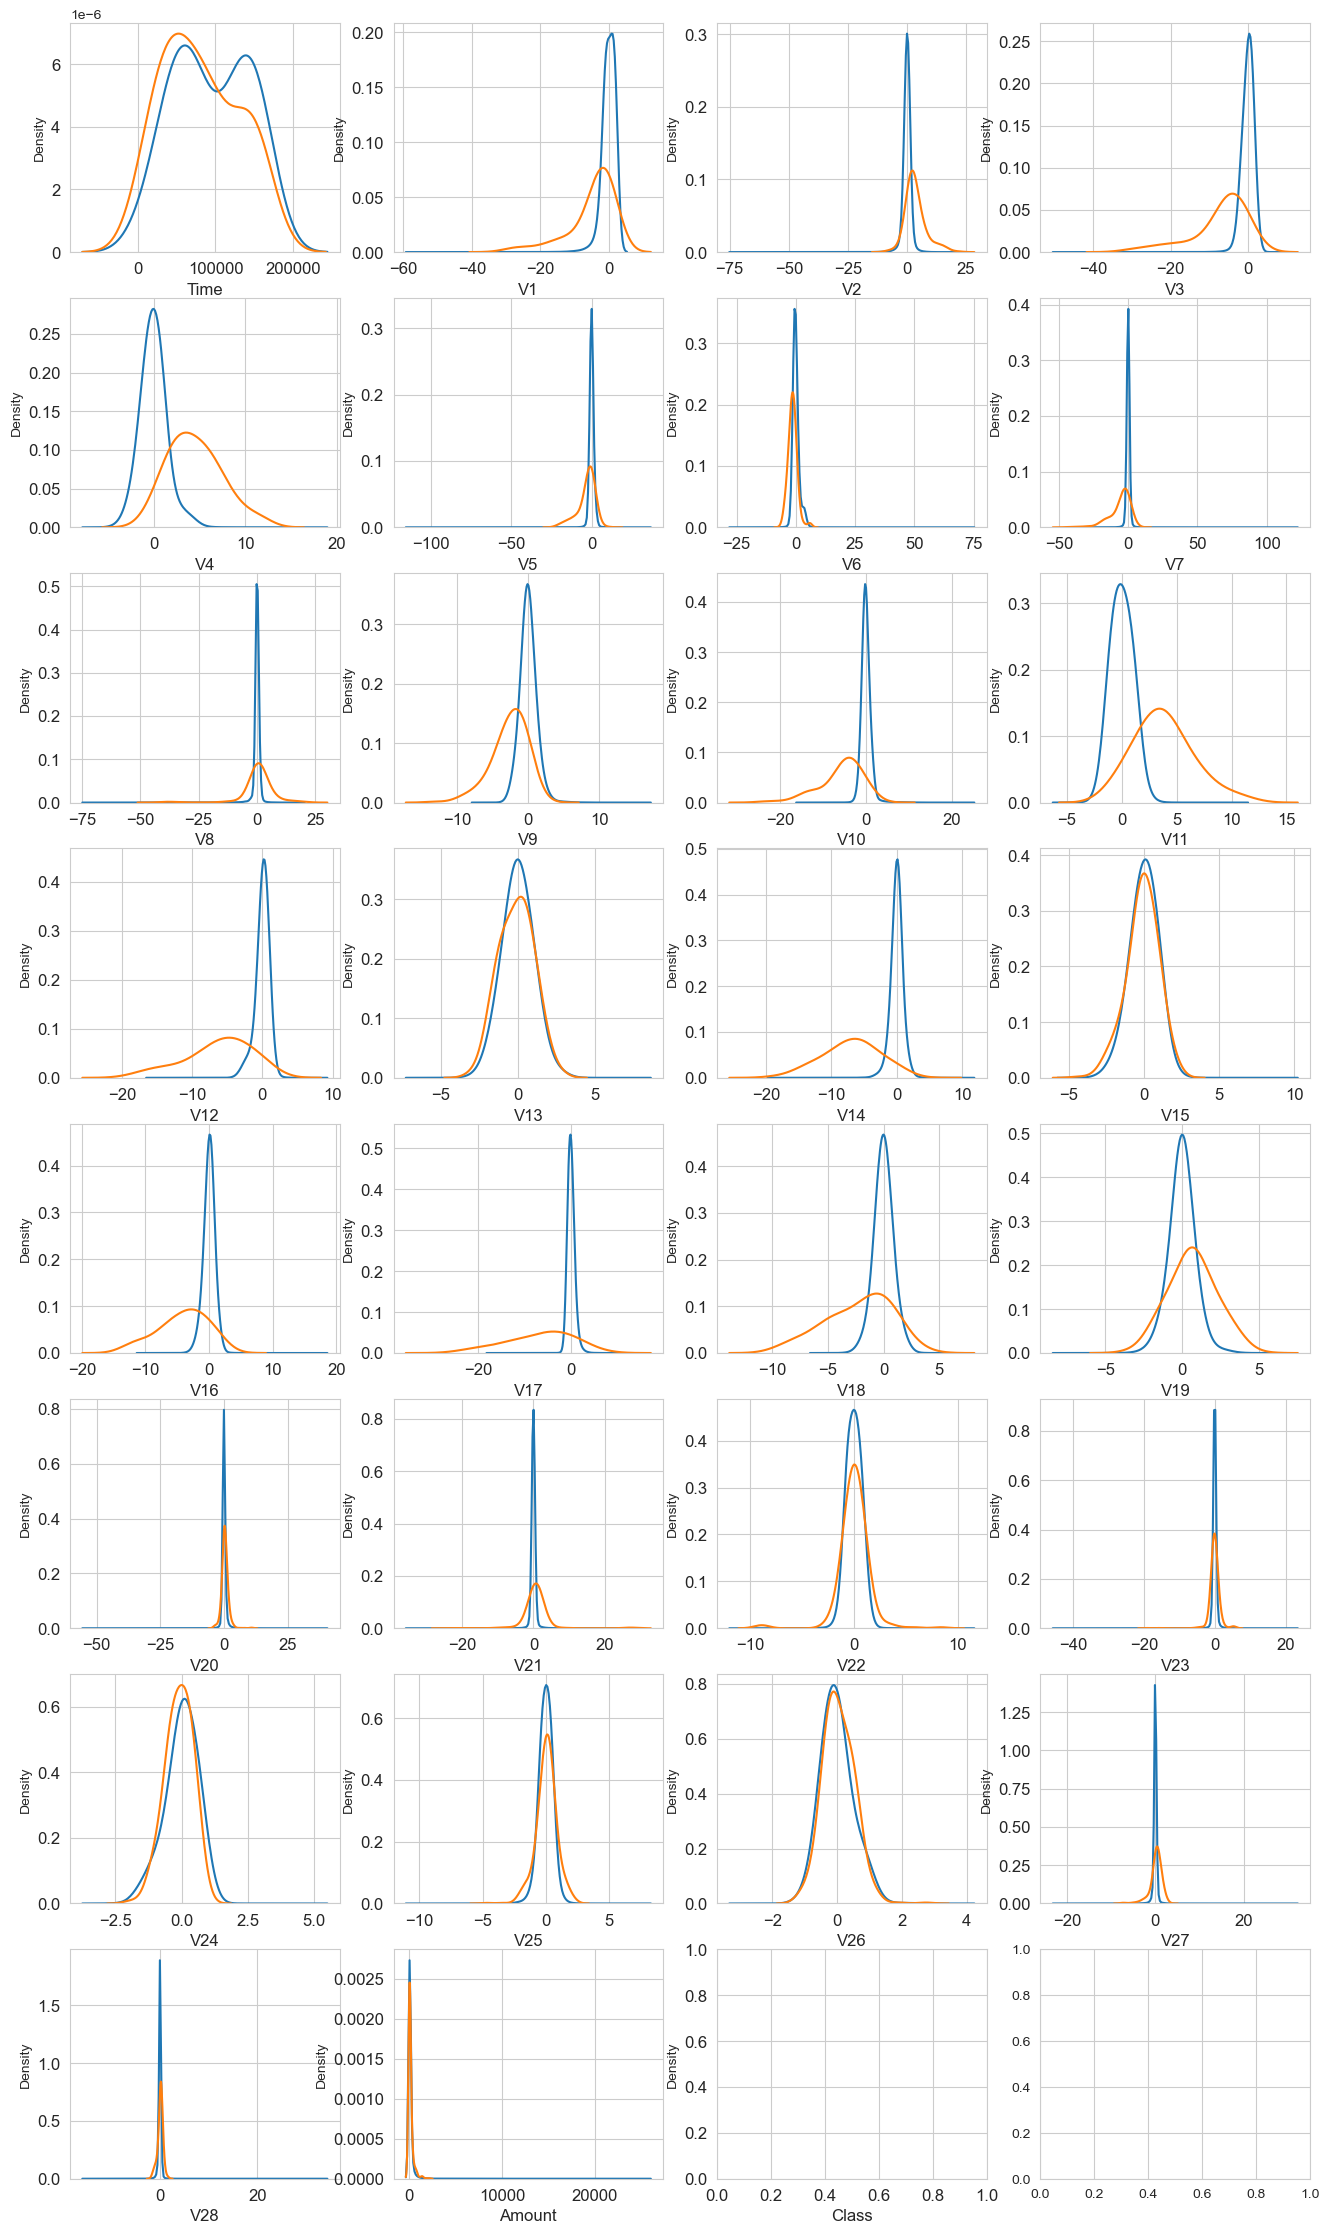

In [20]:
var = df.columns.values

i = 0
t0 = df.loc[df['Class'] == 0]
t1 = df.loc[df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

In [21]:
#### vemos que probablemente las mejores variables para este modelo serían las que no tienen distribuciones traslapadas
#### entre ambos targets

In [22]:
### visualizamos rapidamente las mejores variables segun la funcion selectkbest

bestfeatures = SelectKBest(score_func=f_classif, k="all")
fit = bestfeatures.fit(X,Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score'] 
featureScores.sort_values(by=["Score"],ascending=False).head(8)

#### vemos que las mejores variables son las que muestran distribuciones que no están empalmadas

,Specs,Score
17,V17,33979.168593
14,V14,28695.547788
12,V12,20749.822361
10,V10,14057.979985
16,V16,11443.349428
3,V3,11014.508305
7,V7,10349.605408
11,V11,6999.355047


In [23]:
df.corr()[["Class"]].sort_values(by="Class",ascending=True) ### podemos confirmar calculando la correlación
### debido al problema de clasificación esto es algo muy informal pero sirve para confirmar la anterior evidencia

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


En problemas de datos desbalanceados, donde una clase tiene muchas más instancias que la otra, es crucial abordar este desequilibrio para evitar que el modelo de machine learning se sesgue hacia la clase mayoritaria y tenga dificultades para generalizar hacia la clase minoritaria. La estrategia más comun para abordar este tipo de problemas es usando remuestreo (Sampling en Ingles)

Dado que V17 y V14 son las mejores variables , entonces las utilizaremos para graficar en un espacio bidimensional
las clases 1 y 0 y mostrar las tecnicas utilizadas para problemas de datos desbalanceados

In [24]:
print(df[df['Class'] == 0].shape)
print(df[df['Class'] == 1].shape) ### claramente se nota el desbalance de clases

(284315, 31)
(492, 31)


Los metodos de sampling SIEMPRE se hacen dentro del conjunto de entrenamiento. Aquí algunas razones:
    
- Prevención de Fugas de Información: 

Si aplicas técnicas de remuestreo al conjunto completo de datos antes de dividirlo en conjuntos de entrenamiento y prueba, podrías introducir información del conjunto de prueba en el conjunto de entrenamiento, lo cual podría llevar a resultados optimistas y sesgados.

- Evaluación Realista del Rendimiento: 

Al aplicar técnicas de remuestreo solo al conjunto de entrenamiento, garantizas que el modelo no haya visto las instancias adicionales (en oversampling) o haya perdido información (en undersampling) durante la fase de entrenamiento. Esto proporciona una evaluación más realista del rendimiento del modelo en datos no vistos.

- Simulación del Entorno del Mundo Real: 

En la práctica, el modelo se desempeñará en datos no vistos que pueden tener la misma distribución desbalanceada. Al aplicar el remuestreo solo en el conjunto de entrenamiento, se simula más fielmente la situación del mundo real.

In [25]:
df2 =df.sample(n = 20000,random_state=20) ### para hacer mas facil de visualizar las tecnicas de muestreo tomaremos
### una muestra mas chica del set de datos

In [26]:
X=df2.drop(columns="Class")
Y=df2["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)


In [27]:
df_sampling=pd.concat([X_train,Y_train],axis=1)

In [28]:
df_sampling.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
51962,45212.0,1.157490,0.384735,0.546969,1.264058,-0.204754,-0.569154,0.151698,-0.154323,-0.225524,...,0.137013,0.525811,-0.059419,0.437768,0.596408,-0.275691,0.042154,0.025519,10.00,0
155050,104265.0,2.049435,-0.352080,-0.699448,0.078755,-0.121139,0.055378,-0.695225,-0.062877,2.631826,...,0.003636,0.369561,0.100841,0.002950,-0.123455,0.061801,-0.026715,-0.046109,20.38,0
180086,124374.0,0.511588,0.718452,-0.634718,-0.432513,0.284639,-0.197276,-0.585068,-2.830850,-0.071619,...,-1.620771,-0.618565,0.090609,-0.737726,0.502545,0.264741,-0.045365,0.131222,1.98,0
239444,150113.0,1.337456,-1.687911,-1.016275,0.175954,-0.703053,0.472596,-0.395876,0.151238,1.345051,...,0.389623,0.498732,-0.199413,0.235812,-0.258163,0.070426,-0.062230,0.007693,350.00,0
163686,116150.0,1.982250,-0.636389,-2.024504,-1.311355,-0.187407,-1.874976,0.585255,-0.561527,1.549598,...,0.044495,0.237799,-0.058679,0.102721,0.340821,-0.140854,-0.057868,-0.059007,89.41,0


In [31]:
### visualizamos los histogramas de las variables 17 y 14

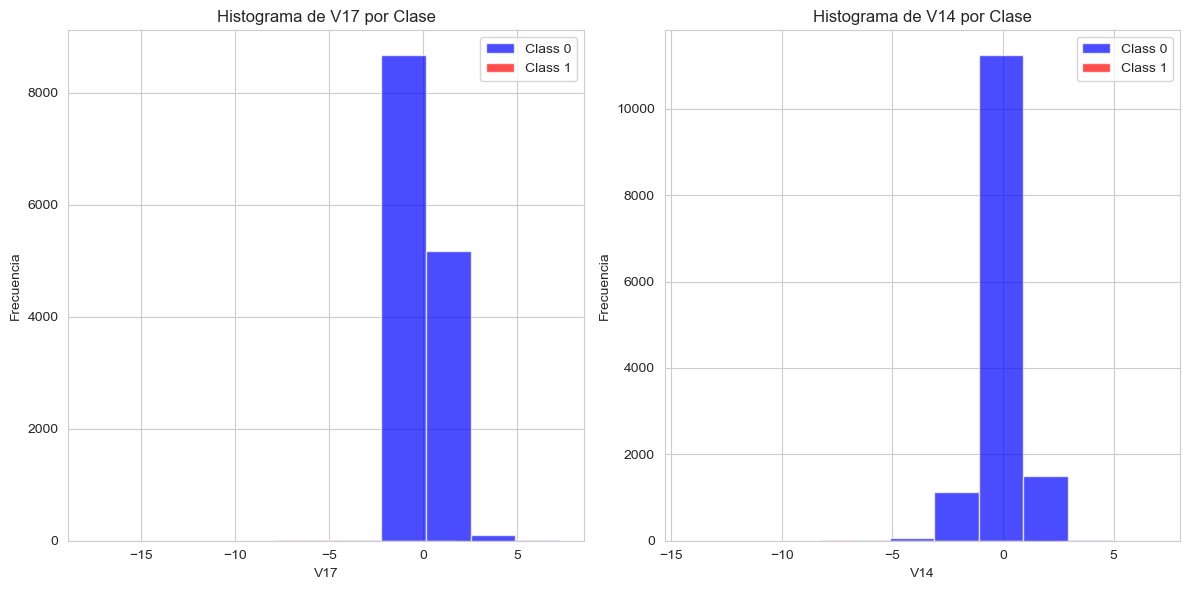

In [32]:
# Filtrar para la clase 0 y 1
df_sampling_class_0 = df_sampling[df_sampling['Class'] == 0]
df_sampling_class_1 = df_sampling[df_sampling['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_sampling_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_sampling_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_sampling_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_sampling_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

En las distribuciones no se oberva la clase 1. graficamos ambas clases con las columnas V17 y V14

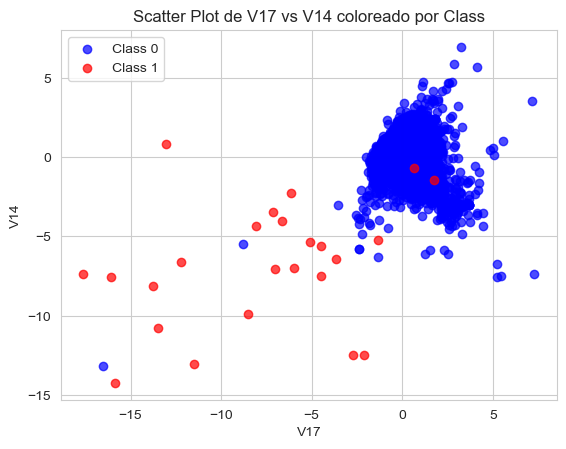

In [33]:
plt.scatter(df_sampling['V17'][df_sampling['Class'] == 0], df_sampling['V14'][df_sampling['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_sampling['V17'][df_sampling['Class'] == 1], df_sampling['V14'][df_sampling['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

si bien notamos cierto traslape , esto no es tan grave como el caso en el que utilizamos variables que mostraron
bajo rendimiento para este problema de datos desbalanceados. Por ejemplo

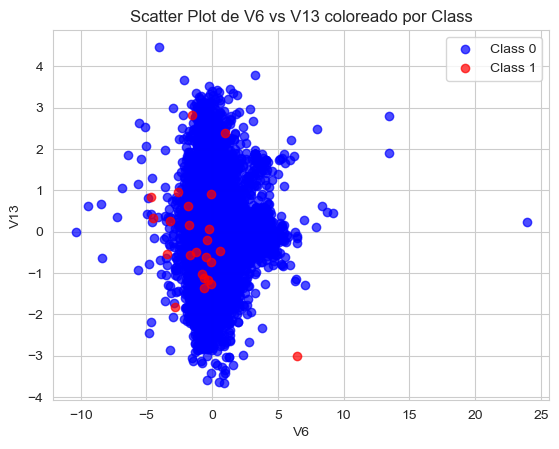

In [34]:
plt.scatter(df_sampling['V6'][df_sampling['Class'] == 0], df_sampling['V13'][df_sampling['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_sampling['V6'][df_sampling['Class'] == 1], df_sampling['V13'][df_sampling['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V6')
plt.ylabel('V13')
plt.title('Scatter Plot de V6 vs V13 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

sumando una variable mas podemos ver las clases distribuidas de la siguiente forma. 

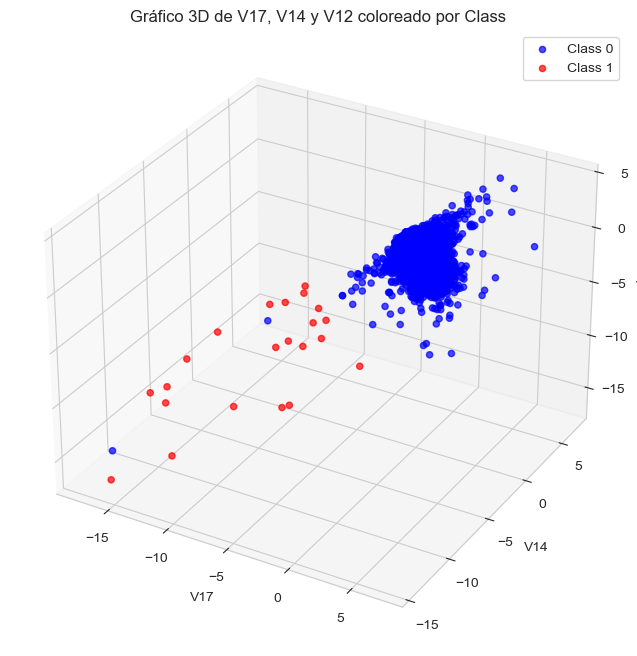

In [35]:
from mpl_toolkits.mplot3d import Axes3D

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar las variables V17, V14 y V12 en 3D y colorear por la variable Class
ax.scatter(df_sampling['V17'][df_sampling['Class'] == 0], df_sampling['V14'][df_sampling['Class'] == 0], df_sampling['V12'][df_sampling['Class'] == 0],
           color='blue', label='Class 0', alpha=0.7)

ax.scatter(df_sampling['V17'][df_sampling['Class'] == 1], df_sampling['V14'][df_sampling['Class'] == 1], df_sampling['V12'][df_sampling['Class'] == 1],
           color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
ax.set_xlabel('V17')
ax.set_ylabel('V14')
ax.set_zlabel('V12')
ax.set_title('Gráfico 3D de V17, V14 y V12 coloreado por Class')

# Mostrar leyenda
ax.legend()

# Mostrar el gráfico
plt.show()

Con la finalidad de hacer el ejercicio más practico utilizaremos por ahora solo dos dimensiones

## UNDERSAMPLING

Consiste en reducir el número de instancias de la clase mayoritaria para equilibrar la proporción entre las clases.

#### Ventajas del Undersampling:
- Mitiga el Sesgo hacia la Clase Mayoritaria: 

Al reducir el número de instancias de la clase mayoritaria, el modelo de machine learning tiende a prestar más atención a la clase minoritaria, evitando así el sesgo hacia la clase mayoritaria.

- Reducción del Tiempo de Entrenamiento: 

Al trabajar con conjuntos de datos más pequeños después de aplicar undersampling, se puede reducir el tiempo de entrenamiento del modelo, especialmente en algoritmos computacionalmente costosos.

- Manejo de Conjuntos de Datos Grandes: 

En casos donde el conjunto de datos es muy grande y el desbalance es significativo, el undersampling puede ayudar a reducir la complejidad computacional y el uso de recursos.

#### Desventajas del Undersampling:
- Pérdida de Información: 

Al eliminar instancias de la clase mayoritaria, puede haber pérdida de información valiosa. Esto puede ser crítico si la clase mayoritaria ya es pequeña o si las instancias eliminadas son representativas de la distribución general de la clase mayoritaria.

- Sensibilidad a Outliers: 

Si el conjunto de datos es susceptible a outliers, el undersampling puede aumentar la influencia de estos outliers en el modelo al reducir la cantidad de instancias no atípicas.

- Menor Capacidad de Generalización: 

Al reducir la cantidad de datos de la clase mayoritaria, el modelo puede tener una capacidad de generalización inferior en relación con la clase mayoritaria.

- Dependencia de la Elección del Muestreo: 

La eficacia del undersampling puede depender de la forma en que se elijan y eliminen las instancias de la clase mayoritaria, y diferentes enfoques pueden conducir a resultados diversos.

<img src="UNDERSAMPLING.png">

In [36]:
rus = RandomUnderSampler(random_state=0)

X_train_rus, Y_train_rus = rus.fit_resample(X_train, Y_train)
print('Dimensiones antes de RandomUnderSampler: ', X_train.shape, Y_train.shape)
print('Dimensiones despues de RandomUnderSampler: ', X_train_rus.shape, Y_train_rus.shape)
print('Distribution de etiquetas despues de RandomUnderSampler: \n', pd.Series(Y_train_rus).value_counts())

Dimensiones antes de RandomUnderSampler:  (14000, 30) (14000,)
Dimensiones despues de RandomUnderSampler:  (48, 30) (48,)
Distribution de etiquetas despues de RandomUnderSampler: 
 Class
0    24
1    24
Name: count, dtype: int64


vemos la distribucion de las variables con undersampling

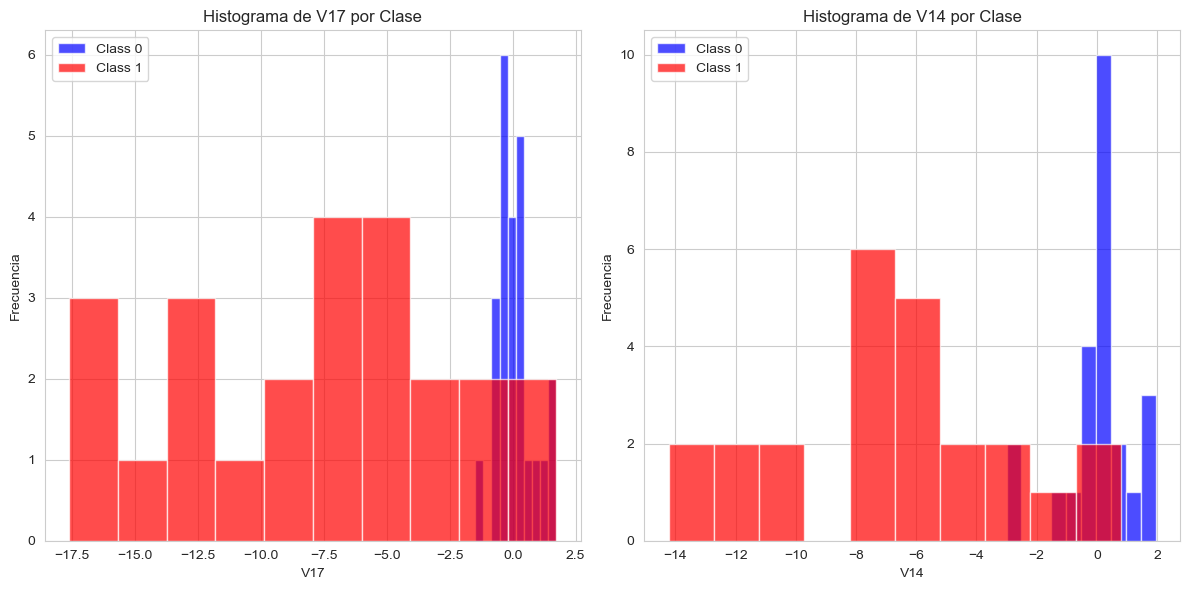

In [37]:
# Filtrar para la clase 0 y 1
df_rus = pd.concat([X_train_rus,Y_train_rus],axis=1)
df_rus_class_0 = df_rus[df_rus['Class'] == 0]
df_rus_class_1 = df_rus[df_rus['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_rus_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_rus_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_rus_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_rus_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

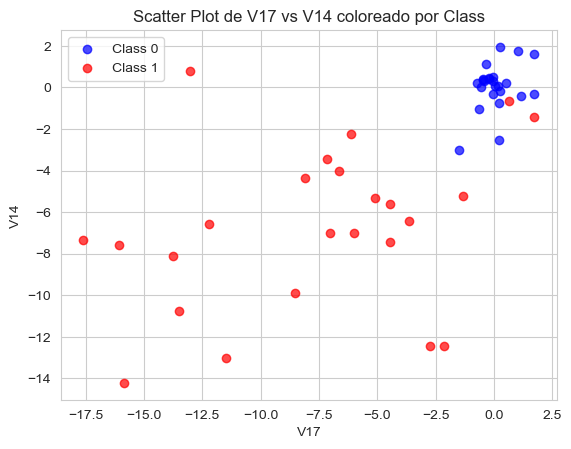

In [38]:
plt.scatter(df_rus['V17'][df_rus['Class'] == 0], df_rus['V14'][df_rus['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_rus['V17'][df_rus['Class'] == 1], df_rus['V14'][df_rus['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

# OVERSAMPLING

Consiste en aumentar el número de instancias de la clase minoritaria para equilibrar la proporción entre las clases. 

#### Ventajas del Oversampling:
- Mejora la Capacidad de Aprendizaje del Modelo: 

Al proporcionar más instancias de la clase minoritaria, se brinda al modelo más oportunidades para aprender patrones y características específicas de esa clase.

- Mitiga el Sesgo hacia la Clase Mayoritaria: 

Al equilibrar las proporciones entre las clases, se reduce el sesgo del modelo hacia la clase mayoritaria, lo que puede mejorar la capacidad del modelo para generalizar en ambas clases.

- Conserva la Información Existente: 

A diferencia del undersampling, donde se eliminan instancias, el oversampling no elimina datos existentes y, por lo tanto, conserva la información original de la clase mayoritaria.

#### Desventajas del Oversampling:

- Posible Sobreajuste: 

Aumentar artificialmente la cantidad de instancias de la clase minoritaria puede conducir a un sobreajuste en el modelo, especialmente si se generan instancias sintéticas que no representan fielmente la distribución real de la clase.

- Aumento del Costo Computacional: 

Al agregar más instancias al conjunto de datos, el tiempo de entrenamiento del modelo puede aumentar, especialmente en conjuntos de datos grandes.




<img src="OVERSAMPLING.png">

In [39]:
ros = RandomOverSampler(random_state=0)

X_train_ros, Y_train_ros = ros.fit_resample(X_train, Y_train)
print('Dimensiones antes de RandomUnderSampler: ', X_train.shape, Y_train.shape)
print('Dimensiones despues de RandomUnderSampler: ', X_train_ros.shape, Y_train_ros.shape)
print('Distribution de etiquetas despues de RandomUnderSampler: \n', pd.Series(Y_train_ros).value_counts())

Dimensiones antes de RandomUnderSampler:  (14000, 30) (14000,)
Dimensiones despues de RandomUnderSampler:  (27952, 30) (27952,)
Distribution de etiquetas despues de RandomUnderSampler: 
 Class
0    13976
1    13976
Name: count, dtype: int64


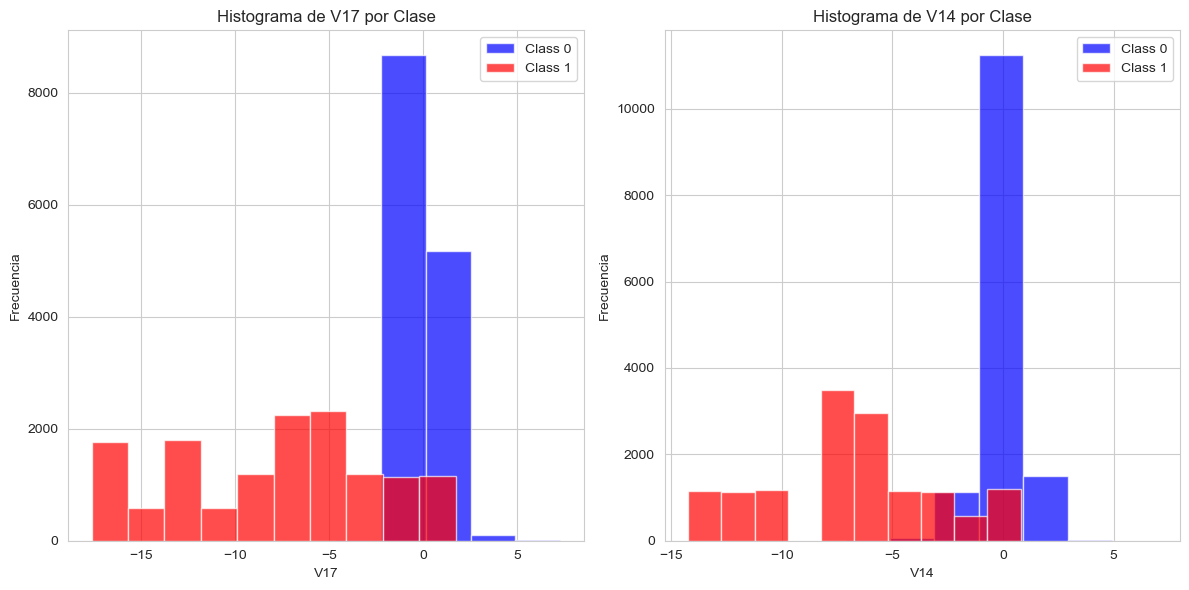

In [40]:
# Filtrar para la clase 0 y 1
df_ros = pd.concat([X_train_ros,Y_train_ros],axis=1)
df_ros_class_0 = df_ros[df_ros['Class'] == 0]
df_ros_class_1 = df_ros[df_ros['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_ros_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_ros_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_ros_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_ros_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

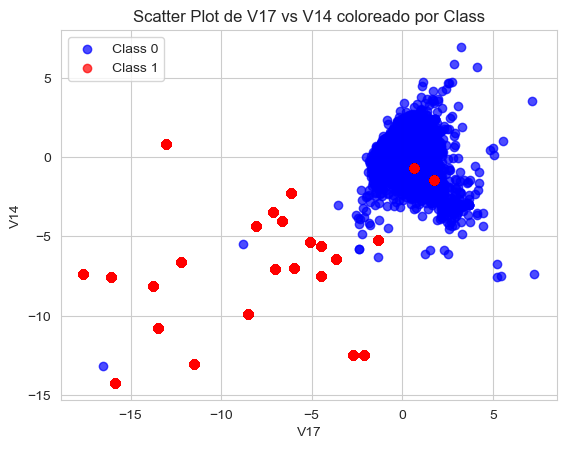

In [41]:
plt.scatter(df_ros['V17'][df_ros['Class'] == 0], df_ros['V14'][df_ros['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_ros['V17'][df_ros['Class'] == 1], df_ros['V14'][df_ros['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [42]:
### vemos que los puntos rojos son mas gruesos, son los mismos valores , solo que aparecen mas veces

## SMOTE (Synthetic Minority Over-sampling Technique) 

es una técnica utilizada para abordar el desbalance de clases en conjuntos de datos. A diferencia de otras estrategias de oversampling que simplemente replican instancias de la clase minoritaria, SMOTE genera instancias sintéticas mediante la interpolación entre instancias existentes. 

#### Ventajas de SMOTE:

- Mitiga el Desbalance de Clases: 

SMOTE ayuda a equilibrar las proporciones entre clases al generar instancias sintéticas de la clase minoritaria.

- Evita la Pérdida de Información: 

A diferencia del undersampling, SMOTE no elimina instancias existentes, lo que ayuda a preservar la información original de la clase minoritaria.

- Mejora la Capacidad de Generalización: 

Al proporcionar más variedad en los datos de la clase minoritaria, SMOTE puede mejorar la capacidad del modelo para generalizar patrones específicos de esa clase.

#### Desventajas de SMOTE:
- Sobreajuste Potencial: 

La generación de instancias sintéticas puede conducir a un sobreajuste si no se utiliza con precaución, especialmente si las instancias generadas no representan fielmente la distribución real de la clase minoritaria.

- Sensibilidad a Ruido: 

SMOTE puede introducir ruido si las instancias sintéticas se generan de manera inapropiada. La calidad de la técnica depende de la calidad de las instancias sintéticas generadas.

<img src="SMOTE.png">


In [43]:
smote = SMOTE(random_state=0)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)
print('Dimensiones antes de RandomUnderSampler: ', X_train.shape, Y_train.shape)
print('Dimensiones despues de RandomUnderSampler: ', X_train_smote.shape, Y_train_smote.shape)
print('Distribution de etiquetas despues de RandomUnderSampler: \n', pd.Series(Y_train_smote).value_counts())

Dimensiones antes de RandomUnderSampler:  (14000, 30) (14000,)
Dimensiones despues de RandomUnderSampler:  (27952, 30) (27952,)
Distribution de etiquetas despues de RandomUnderSampler: 
 Class
0    13976
1    13976
Name: count, dtype: int64


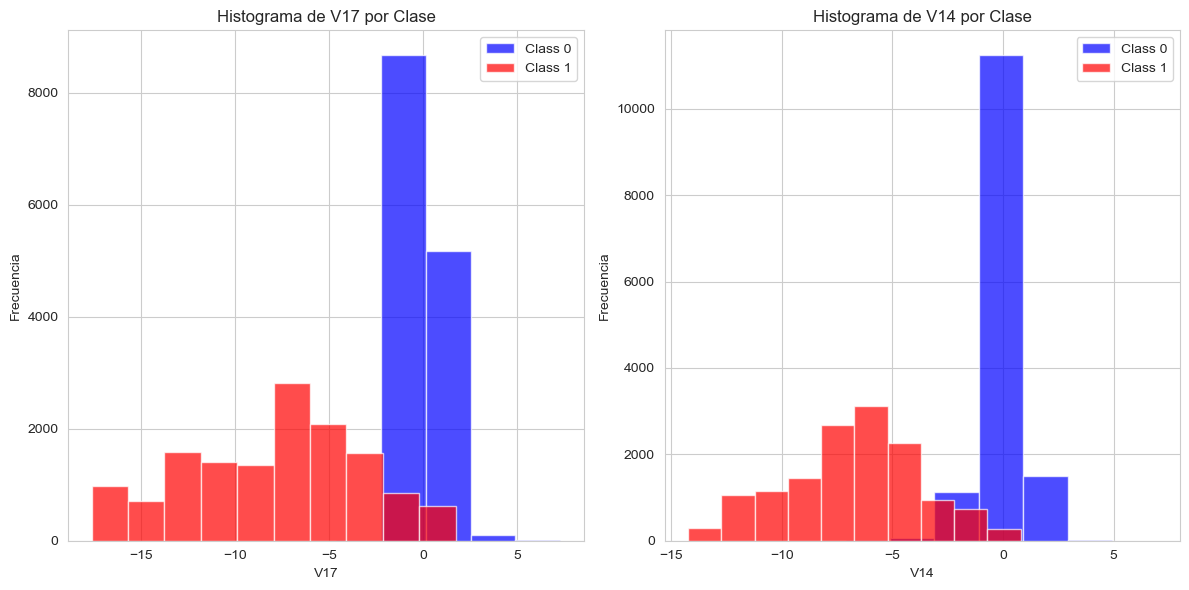

In [44]:
# Filtrar para la clase 0 y 1
df_smote = pd.concat([X_train_smote,Y_train_smote],axis=1)
df_smote_class_0 = df_smote[df_smote['Class'] == 0]
df_smote_class_1 = df_smote[df_smote['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_smote_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_smote_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_smote_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_smote_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

con smote vemos menos traslape entre clases 

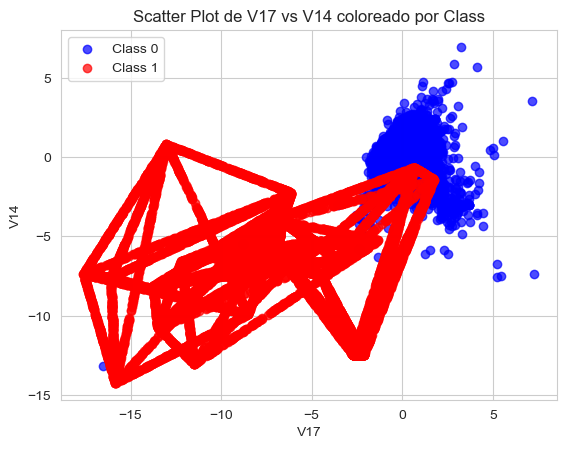

In [45]:
plt.scatter(df_smote['V17'][df_smote['Class'] == 0], df_smote['V14'][df_smote['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_smote['V17'][df_smote['Class'] == 1], df_smote['V14'][df_smote['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

### BORDERLINE SMOTE

es una variante del algoritmo SMOTE (Synthetic Minority Over-sampling Technique) que aborda específicamente las limitaciones de SMOTE al centrarse en las instancias cercanas al límite de decisión entre las clases. Esta técnica tiene como objetivo generar instancias sintéticas solo para las observaciones cercanas al borde entre las clases.

In [46]:
border = BorderlineSMOTE(random_state=0)

X_train_border, Y_train_border = border.fit_resample(X_train, Y_train)
print('Dimensiones antes de RandomUnderSampler: ', X_train.shape, Y_train.shape)
print('Dimensiones despues de RandomUnderSampler: ', X_train_border.shape, Y_train_border.shape)
print('Distribution de etiquetas despues de RandomUnderSampler: \n', pd.Series(Y_train_border).value_counts())

Dimensiones antes de RandomUnderSampler:  (14000, 30) (14000,)
Dimensiones despues de RandomUnderSampler:  (27952, 30) (27952,)
Distribution de etiquetas despues de RandomUnderSampler: 
 Class
0    13976
1    13976
Name: count, dtype: int64


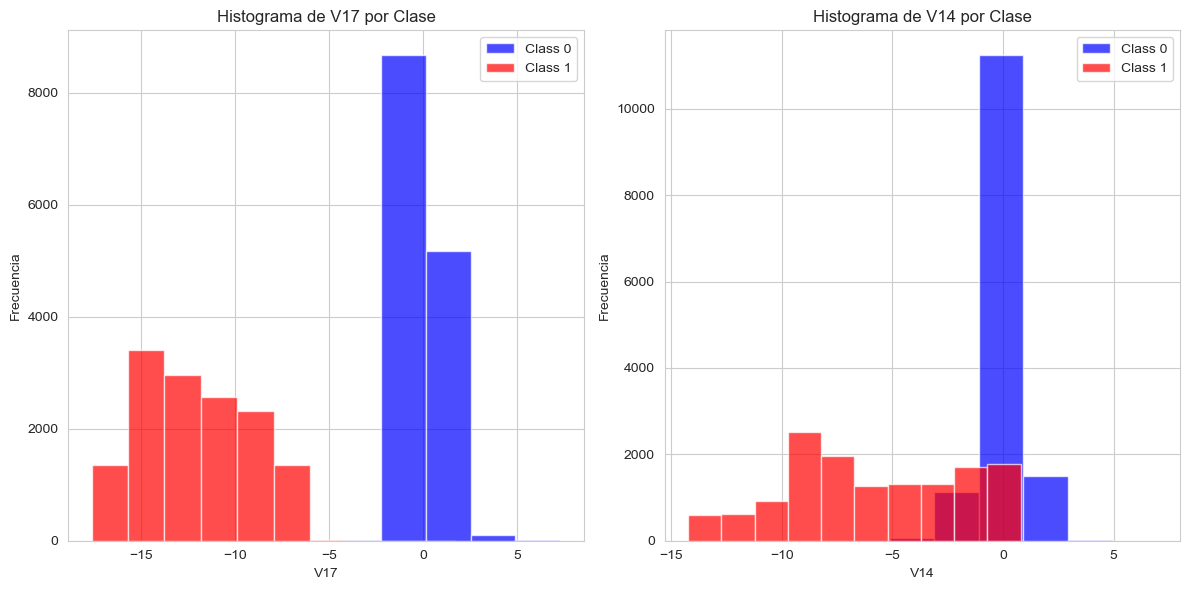

In [47]:
# Filtrar para la clase 0 y 1
df_border = pd.concat([X_train_border,Y_train_border],axis=1)
df_border_class_0 = df_border[df_border['Class'] == 0]
df_border_class_1 = df_border[df_border['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_border_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_border_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_border_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_border_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

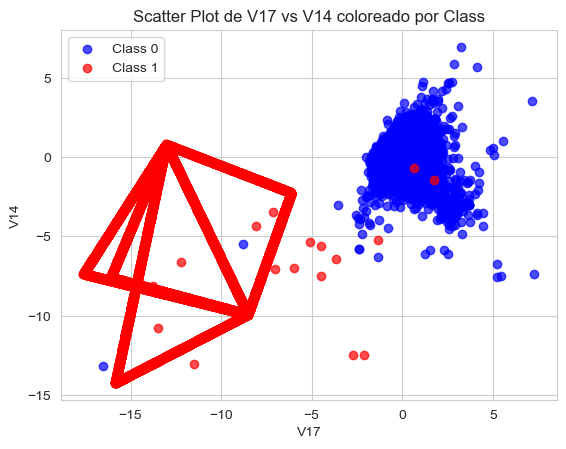

In [48]:
plt.scatter(df_border['V17'][df_border['Class'] == 0], df_border['V14'][df_border['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_border['V17'][df_border['Class'] == 1], df_border['V14'][df_border['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

## ADASYN (Adaptive Synthetic Sampling) 
es otra técnica diseñada para abordar el problema del desbalance de clases en conjuntos de datos. Similar a SMOTE (Synthetic Minority Over-sampling Technique), ADASYN se centra en la generación de instancias sintéticas para la clase minoritaria, pero con una adaptación más dinámica basada en la densidad de las instancias en el espacio de características. Pone más énfasis en generar instancias sintéticas en regiones donde la densidad es baja, es decir  no genera instancias sintéticas para todas las instancias de la clase minoritaria, sino que selecciona de manera selectiva las instancias que necesitan más atención.

In [49]:
adasyn = ADASYN(random_state=0,n_neighbors=10)

X_train_adasyn, Y_train_adasyn = adasyn.fit_resample(X_train, Y_train)
print('Dimensiones antes de RandomUnderSampler: ', X_train.shape, Y_train.shape)
print('Dimensiones despues de RandomUnderSampler: ', X_train_adasyn.shape, Y_train_adasyn.shape)
print('Distribution de etiquetas despues de RandomUnderSampler: \n', pd.Series(Y_train_adasyn).value_counts())

Dimensiones antes de RandomUnderSampler:  (14000, 30) (14000,)
Dimensiones despues de RandomUnderSampler:  (27948, 30) (27948,)
Distribution de etiquetas despues de RandomUnderSampler: 
 Class
0    13976
1    13972
Name: count, dtype: int64


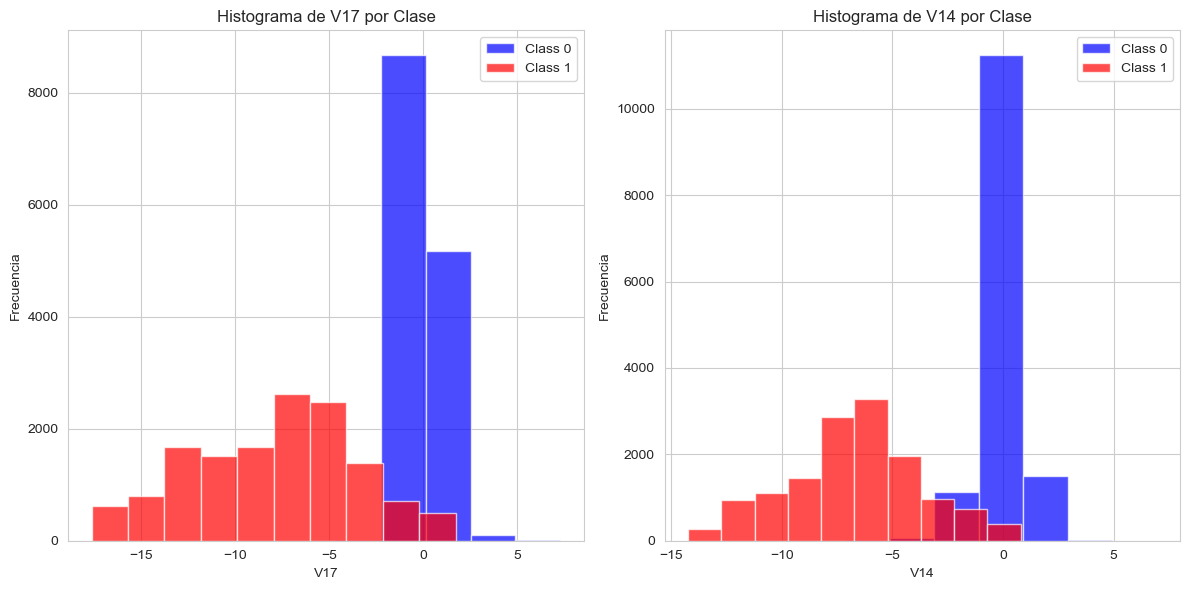

In [50]:
# Filtrar para la clase 0 y 1
df_adasyn = pd.concat([X_train_adasyn,Y_train_adasyn],axis=1)
df_adasyn_class_0 = df_adasyn[df_adasyn['Class'] == 0]
df_adasyn_class_1 = df_adasyn[df_adasyn['Class'] == 1]

# Crear histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_adasyn_class_0['V17'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_adasyn_class_1['V17'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V17')
plt.ylabel('Frecuencia')
plt.title('Histograma de V17 por Clase')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_adasyn_class_0['V14'], color='blue', alpha=0.7, label='Class 0')
plt.hist(df_adasyn_class_1['V14'], color='red', alpha=0.7, label='Class 1')
plt.xlabel('V14')
plt.ylabel('Frecuencia')
plt.title('Histograma de V14 por Clase')
plt.legend()

plt.tight_layout()
plt.show()

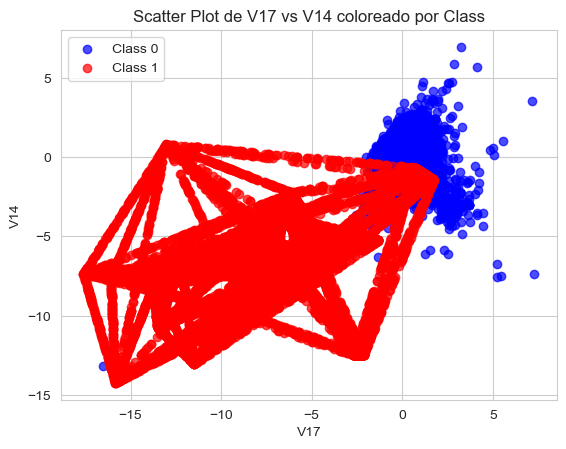

In [51]:
plt.scatter(df_adasyn['V17'][df_adasyn['Class'] == 0], df_adasyn['V14'][df_adasyn['Class'] == 0], color='blue', label='Class 0', alpha=0.7)
plt.scatter(df_adasyn['V17'][df_adasyn['Class'] == 1], df_adasyn['V14'][df_adasyn['Class'] == 1], color='red', label='Class 1', alpha=0.7)

# Añadir etiquetas y título al gráfico
plt.xlabel('V17')
plt.ylabel('V14')
plt.title('Scatter Plot de V17 vs V14 coloreado por Class')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

### uso de smote

In [54]:
X=df.drop(columns="Class")
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)

smote = SMOTE(random_state=0)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)


xgb_model = XGBClassifier(random_state=0).fit(X_train_smote,Y_train_smote)
print("xgb_model accuracy en train,",xgb_model.score(X_train_smote,Y_train_smote))
print("xgb_model accuracy en test,",xgb_model.score(X_test,Y_test)) ### el modelo se ve super bien

xgb_model accuracy en train, 1.0
xgb_model accuracy en test, 0.9994499256814484


<Axes: >

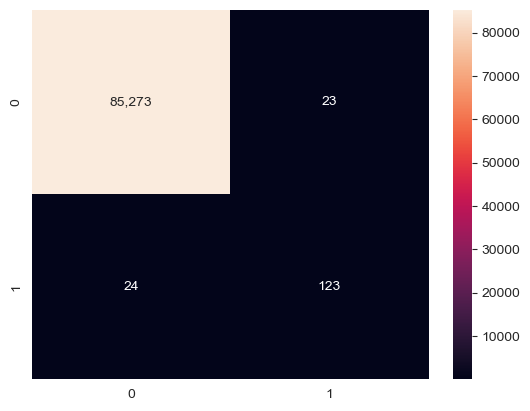

In [55]:
y_pred =  xgb_model.predict(X_test)
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales
### logramos incrementar el numero de clases fraudulentas

In [259]:
Y_test.sum()

147

In [260]:
123+24

147

In [262]:
df.Class.sum()

492

### utilicemos unicamente las 5 variables mas relevantes

In [59]:
X=df[["V17","V14","V12","V10","V6"]]
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)

smote = SMOTE(random_state=0)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)


xgb_model = XGBClassifier(random_state=0).fit(X_train_smote,Y_train_smote)
print("xgb_model accuracy en train,",xgb_model.score(X_train_smote,Y_train_smote))
print("xgb_model accuracy en test,",xgb_model.score(X_test,Y_test)) ### el modelo se ve super bien

xgb_model accuracy en train, 0.9947216094945709
xgb_model accuracy en test, 0.9931416265814637


<Axes: >

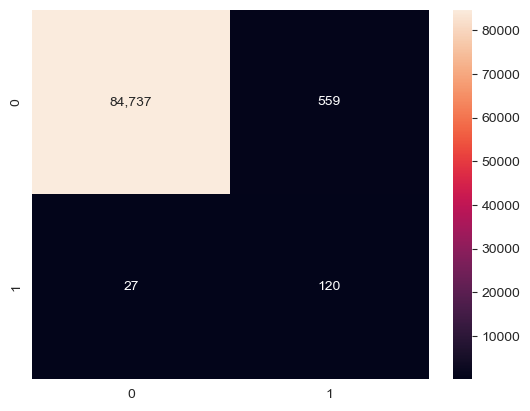

In [60]:
y_pred =  xgb_model.predict(X_test)
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales
### logramos incrementar el numero de clases fraudulentas

usando menos variables no tenemos cambios tan significativos en los falsos negativos, pero si un muy grande en los falsos positivos

vamos a utilizar gridsearch para hiperparametriz el modelo e intentar incrementar el recall. Recordemos
que el recall mide que tan bien se identifica la clase positiva. En otras palabras, minimiza los falsos negativos

No podemos utilizar gridsearch cv como lo hemos usado anteriormente, ya que si lo hacemos de ese modo, en cada fold
estaremos distribuyendo todo el remuestre de smote y sesgando los resultados. Lo que necesitamos es remuestrear 
en los k-1 folds de train y mantener el fold restante sin remuestreo para poder utilizarlo como fold de test.
Debemos repetir este procedimiento para cada uno de los folds. Esto lo logramos con la función pipeline del modulo
imbalanced learn

In [62]:
# Definir el clasificador XGBoost
xgb_classifier = XGBClassifier()

# Definir los parámetros a explorar
param_grid = {
    'classifier__learning_rate': [0.1, 0.01, 0.001],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
}

# Crear el pipeline con SMOTE y el clasificador XGBoost
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_classifier)
])

# Configurar GridSearchCV con el pipeline y los parámetros
grid_search = GridSearchCV(pipeline, param_grid, scoring='recall', cv=5) ### notemos que estamos maximizando recall
# Ajustar el modelo y encontrar los mejores hiperparámetros
grid_search.fit(X_train, Y_train)

# Imprimir los mejores hiperparámetros y el rendimiento en el conjunto de prueba
print("Mejores Hiperparámetros:", grid_search.best_params_)
print("Mejor recall Score en Conjunto de Prueba:", grid_search.best_score_)

Mejores Hiperparámetros: {'classifier__learning_rate': 0.001, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Mejor recall Score en Conjunto de Prueba: 0.8782608695652174


In [63]:
X=df.drop(columns="Class")
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)

smote = SMOTE(random_state=0)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)


xgb_model = XGBClassifier(learning_rate=.001,max_depth=5,n_estimators=100).fit(X_train_smote,Y_train_smote)
print("xgb_model accuracy en train,",xgb_model.score(X_train_smote,Y_train_smote))
print("xgb_model accuracy en test,",xgb_model.score(X_test,Y_test)) #



xgb_model accuracy en train, 0.9743039609283536
xgb_model accuracy en test, 0.9881792540055944


<Axes: >

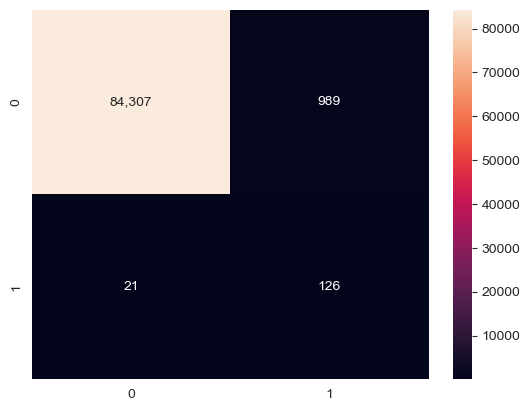

In [64]:
y_pred =  xgb_model.predict(X_test)
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales
### logramos incrementar el numero de clases fraudulentas

In [65]:
print("xgb_model recall",recall_score(Y_test,y_pred))


xgb_model recall 0.8571428571428571


logramos minimizar los falsos negativos pero subimos mucho los falsos positivos. ¿Cómo arreglamos esto?

### F2 SCORE

El F2 score es una métrica de evaluación en problemas de clasificación binaria que combina la precisión y el recall (sensibilidad). Esta métrica es una variante del F1 score y le da más peso al recall que a la precisión. El F2 score se define de la siguiente manera:


en general el Fb score se escribe de la siguiente manera

$F\beta= \frac{(1+\beta^2)*Precision * Recall}{\beta^2  Precision + Recall}$
 

Donde:

- Precision  se calcula como el número de verdaderos positivos dividido por la suma de verdaderos positivos y falsos positivos. Se centra en la precisión de las predicciones positivas.
- Recall (o sensibilidad) se calcula como el número de verdaderos positivos dividido por la suma de verdaderos positivos y falsos negativos. Se centra en la capacidad del modelo para capturar todos los casos positivos.

- β es un parámetro que controla el peso relativo entre precision y recall. En el caso del F2 score, β se establece en 2, lo que significa que se le da más importancia al recall que a la precisión (un valor menor a 1 da mas importancia a precision)

El F2 score es útil cuando el costo de los falsos negativos (no detectar casos positivos) es más alto que el costo de los falsos positivos (detectar incorrectamente casos negativos). En deteccion de fraude  es crítico identificar los casos fraudulentos un F2 score mayor podría ser preferible para minimizar los casos en los que el fraude se pasa por algo.

En términos generales, el F2 score proporciona una métrica que equilibra la precisión y la capacidad para capturar casos positivos, y su elección se basa en las necesidades específicas del problema y el dominio de aplicación.

In [66]:
f2_scorer = make_scorer(fbeta_score, beta=2) ### creamos un score para ingresarlo a gridsearch

In [67]:
# Definir el clasificador XGBoost
xgb_classifier = XGBClassifier()

# Definir los parámetros a explorar
param_grid = {
    'classifier__learning_rate': [0.1, 0.01, 0.001],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
}

# Crear el pipeline con SMOTE y el clasificador XGBoost
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_classifier)
])

# Configurar GridSearchCV con el pipeline y los parámetros
grid_search = GridSearchCV(pipeline, param_grid, scoring=f2_scorer, cv=5)

# Ajustar el modelo y encontrar los mejores hiperparámetros
grid_search.fit(X_train, Y_train)

# Imprimir los mejores hiperparámetros y el rendimiento en el conjunto de prueba
print("Mejores Hiperparámetros:", grid_search.best_params_)
print("Mejor recall Score en Conjunto de Prueba:", grid_search.best_score_)

Mejores Hiperparámetros: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 300}
Mejor recall Score en Conjunto de Prueba: 0.8318924091197685


In [68]:
X=df.drop(columns="Class")
Y=df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)

smote = SMOTE(random_state=0)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)


xgb_model = XGBClassifier(learning_rate=.1,max_depth=7,n_estimators=300).fit(X_train_smote,Y_train_smote)
print("xgb_model accuracy en train,",xgb_model.score(X_train_smote,Y_train_smote))
print("xgb_model accuracy en test,",xgb_model.score(X_test,Y_test)) #

xgb_model accuracy en train, 1.0
xgb_model accuracy en test, 0.9994850368081645


<Axes: >

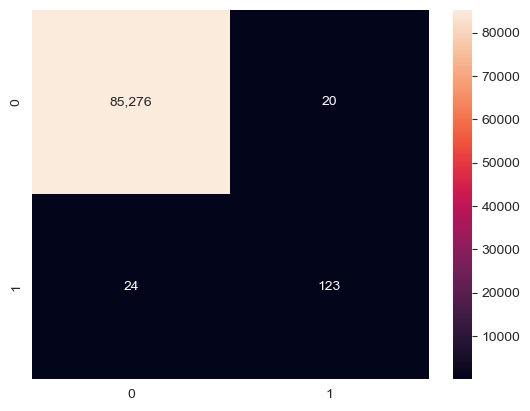

In [69]:
y_pred =  xgb_model.predict(X_test)
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales

podemos notar que a comparación del resultado anterior, los falsos negativos incrementan, pero tenemos mas balance
con los falsos positivos

In [70]:
print("xgb_model f2",fbeta_score(Y_test,y_pred,beta=2)) ## buscamos que un f2 score sea cercano a 1

xgb_model f2 0.8413132694938441


podriamos bajar un poco mas la cantidad de falsos negativos ajustando el umbral de clasificación

In [72]:
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

for threshold in [.2,.3,0.4, 0.45,0.5, 0.6]:
    y_pred = (y_pred_prob > threshold).astype(int)
    f2 = fbeta_score(Y_test, y_pred,beta=2)
    print(f'Threshold: {threshold}, f2: {f2}') ### sube un poquito moviendo el umbral a .4

Threshold: 0.2, f2: 0.8401084010840107
Threshold: 0.3, f2: 0.8446866485013625
Threshold: 0.4, f2: 0.8458390177353344
Threshold: 0.45, f2: 0.8469945355191256
Threshold: 0.5, f2: 0.8413132694938441
Threshold: 0.6, f2: 0.8424657534246577


In [73]:
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > .45).astype(int)

<Axes: >

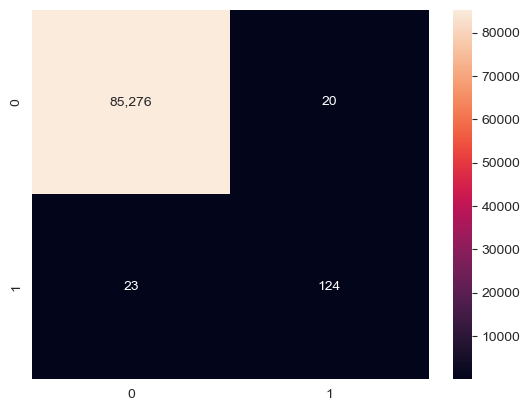

In [75]:
cmat_accuracy=confusion_matrix(Y_test,y_pred)
sns.heatmap(cmat_accuracy,annot=True,fmt=",")
### X predicciones, Y reales # logramos bajar un falso negativo

In [76]:
124/(23+124) ### logramos capturar el 84% de los casos fraudulentos (no está mal)

0.8435374149659864

Diferencias Clave entre F2 Y RECALL:

- El recall se centra exclusivamente en la capacidad del modelo para capturar casos positivos, sin tener en cuenta la cantidad de falsos positivos.

- El F2 score proporciona un equilibrio entre precisión y recall, dando más importancia al recall. Esto lo hace particularmente útil en situaciones donde minimizar los falsos negativos es más crítico sin descuidar los falsos positivos
